
# ENVI benchmark: Br8667 validation split

This notebook runs **ENVI** on the same GeneBridge Br8667 validation split used for VISTA, gimVI, SpaGE, and Tangram.

Fair setup:

- Spatial input: `spatial_train_210genes.h5ad`
- Hidden validation truth: `validation_truth_45genes.h5ad`
- Reference: Huuki snRNA/scRNA reference
- Output: ENVI predictions for the same 45 validation genes
- Evaluation: gene-wise Spearman/Pearson/MAE/RMSE
- Plot: observed Xenium truth vs ENVI prediction, plus optional all-method geneplot

ENVI workflow: initialize `scenvi.ENVI(...)`, run `train()`, run `impute_genes()`, then read predictions from `envi_model.spatial_data.obsm["imputation"]`.



## Installation note

Run this in an ENVI-specific conda environment.

```bash
conda create -p /scratch/mjabin/conda_envs/envi python=3.10 -y
conda activate /scratch/mjabin/conda_envs/envi

python -m pip install -U "jax[cuda12]"
python -m pip install scenvi scanpy anndata pandas numpy scipy matplotlib tqdm ipykernel

python -m ipykernel install --user --name envi --display-name "ENVI"
```

Then open this notebook with the `ENVI` kernel.

If running by SLURM notebook execution, use:

```bash
--ExecutePreprocessor.kernel_name=envi
```


In [1]:
# ============================================================
# 1. Force JAX/ENVI CPU mode
# ============================================================

import os

# Force JAX to initialize CPU only
os.environ["JAX_PLATFORMS"] = "cpu"

# Deprecated but okay as backup
os.environ["JAX_PLATFORM_NAME"] = "cpu"

# Avoid memory preallocation behavior
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Optional CPU thread control
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt

import jax
print("JAX devices:", jax.devices())
print("JAX backend:", jax.default_backend())

import scenvi

print("scanpy:", sc.__version__)
print("scenvi imported successfully")

JAX devices: [CpuDevice(id=0)]
JAX backend: cpu
scanpy: 1.10.3
scenvi imported successfully


In [2]:

# ============================================================
# 2. User configuration
# ============================================================

PROJECT_ROOT = Path("/users/mjabin/projects/GeneBridge")

RUN_MODE = "smoke"  # change to "full" later

BENCH_DIR = PROJECT_ROOT / "data/processed/imputation_beta/Br8667/benchmark"
SPATIAL_TRAIN_H5AD = BENCH_DIR / "inputs/spatial_train_210genes.h5ad"
VALIDATION_TRUTH_H5AD = BENCH_DIR / "truth/validation_truth_45genes.h5ad"

DEFAULT_SC_H5AD = (
    PROJECT_ROOT
    / "data/processed/imputation_beta/Br8667"
    / "seq_data_huuki_snrna_Br8667_vista.h5ad"
)

FULL_HUUKI_H5AD = (
    PROJECT_ROOT
    / "data/processed/snrnaseq/sce_DLPFC_annotated"
    / "huuki_snrna_reference_full_allgenes.h5ad"
)

SC_H5AD = DEFAULT_SC_H5AD if DEFAULT_SC_H5AD.exists() else FULL_HUUKI_H5AD

PRED_DIR = BENCH_DIR / "predictions"
OUT_DIR = PROJECT_ROOT / "outputs/imputation_beta/Br8667/validation/envi"
FIG_DIR = OUT_DIR / "figures"

PRED_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

OUT_PRED_H5AD = PRED_DIR / "envi_validation_predictions_45genes.h5ad"
OUT_METRICS = OUT_DIR / "17_envi_validation_gene_metrics.csv"
OUT_SUMMARY = OUT_DIR / "17_envi_validation_summary.csv"

GENE_FOR_PLOT = "ACTA2"

if RUN_MODE == "smoke":
    TRAINING_STEPS = 100
    MAX_SPATIAL_CELLS = None
    MAX_SC_CELLS = None
    NUM_HVG = 512
    NUM_COV_GENES = 32
else:
    TRAINING_STEPS = 16000
    MAX_SPATIAL_CELLS = None
    MAX_SC_CELLS = None
    NUM_HVG = 2048
    NUM_COV_GENES = 64

BATCH_SIZE = 128
K_NEAREST = 8
COVET_BATCH_SIZE = 256
SEED = 42

print("RUN_MODE:", RUN_MODE)
print("SC_H5AD:", SC_H5AD)
print("SPATIAL_TRAIN_H5AD:", SPATIAL_TRAIN_H5AD)
print("VALIDATION_TRUTH_H5AD:", VALIDATION_TRUTH_H5AD)
print("TRAINING_STEPS:", TRAINING_STEPS)


RUN_MODE: smoke
SC_H5AD: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/seq_data_huuki_snrna_Br8667_vista.h5ad
SPATIAL_TRAIN_H5AD: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/inputs/spatial_train_210genes.h5ad
VALIDATION_TRUTH_H5AD: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/truth/validation_truth_45genes.h5ad
TRAINING_STEPS: 100


In [3]:

# ============================================================
# 3. Helper functions
# ============================================================

def make_str_index(index):
    return pd.Index(index.astype(str))

def to_dense_float32(x):
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x, dtype=np.float32)

def get_X_dense(adata):
    return to_dense_float32(adata.X)

def ensure_nonnegative(adata, name):
    x = adata.X
    xmin = x.min() if not sp.issparse(x) else x.min()
    print(f"{name} min X:", xmin)
    if xmin < 0:
        print(f"WARNING: {name} has negative values. ENVI may treat input as normalized/log data.")

def compute_gene_metrics(truth_adata, pred_adata):
    rows = []
    truth_X = get_X_dense(truth_adata)
    pred_X = get_X_dense(pred_adata)

    for j, gene in enumerate(truth_adata.var_names.astype(str)):
        y_true = truth_X[:, j]
        y_pred = pred_X[:, j]
        finite = np.isfinite(y_true) & np.isfinite(y_pred)

        if finite.sum() < 3:
            spearman = pearson = mae = rmse = np.nan
        else:
            spearman = spearmanr(y_true[finite], y_pred[finite]).correlation
            try:
                pearson = pearsonr(y_true[finite], y_pred[finite])[0]
            except Exception:
                pearson = np.nan
            mae = np.mean(np.abs(y_true[finite] - y_pred[finite]))
            rmse = np.sqrt(np.mean((y_true[finite] - y_pred[finite]) ** 2))

        rows.append(
            {
                "gene": gene,
                "spearman": spearman,
                "pearson": pearson,
                "mae": mae,
                "rmse": rmse,
                "n_cells": int(finite.sum()),
                "truth_mean": float(np.nanmean(y_true[finite])) if finite.sum() else np.nan,
                "pred_mean": float(np.nanmean(y_pred[finite])) if finite.sum() else np.nan,
            }
        )
    return pd.DataFrame(rows)

def plot_truth_vs_prediction(gene, truth_adata, pred_adata, out_png, out_pdf):
    if gene not in truth_adata.var_names:
        print(f"{gene} not in validation truth. Using first validation gene.")
        gene = str(truth_adata.var_names[0])

    coords = truth_adata.obsm["spatial"]
    truth_gene = get_X_dense(truth_adata[:, [gene]]).ravel()
    pred_gene = get_X_dense(pred_adata[:, [gene]]).ravel()

    truth_plot = np.log1p(truth_gene)
    pred_plot = np.log1p(pred_gene)

    combined = np.concatenate([truth_plot, pred_plot])
    vmin = np.nanpercentile(combined, 1)
    vmax = np.nanpercentile(combined, 99)

    rho = spearmanr(truth_gene, pred_gene).correlation

    fig = plt.figure(figsize=(12, 5))

    ax = plt.subplot(1, 2, 1)
    sca = ax.scatter(coords[:, 0], coords[:, 1], c=truth_plot, s=2, vmin=vmin, vmax=vmax)
    ax.set_title(f"Observed Xenium truth: {gene}")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)

    ax = plt.subplot(1, 2, 2)
    sca = ax.scatter(coords[:, 0], coords[:, 1], c=pred_plot, s=2, vmin=vmin, vmax=vmax)
    ax.set_title(f"ENVI prediction: {gene}\nSpearman={rho:.3f}")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.colorbar(sca, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.savefig(out_pdf)
    plt.show()

    print("Saved:")
    print(out_png)
    print(out_pdf)


In [4]:

# ============================================================
# 4. Load benchmark data
# ============================================================

for path in [SPATIAL_TRAIN_H5AD, VALIDATION_TRUTH_H5AD, SC_H5AD]:
    if not Path(path).exists():
        raise FileNotFoundError(path)

spatial_train = sc.read_h5ad(SPATIAL_TRAIN_H5AD)
validation_truth = sc.read_h5ad(VALIDATION_TRUTH_H5AD)
sc_ref = sc.read_h5ad(SC_H5AD)

print("Loaded:")
print("spatial_train:", spatial_train)
print("validation_truth:", validation_truth)
print("sc_ref:", sc_ref)

for a in [spatial_train, validation_truth, sc_ref]:
    a.var_names = make_str_index(a.var_names)
    a.obs_names = make_str_index(a.obs_names)
    a.var_names_make_unique()
    a.obs_names_make_unique()

if "spatial" not in spatial_train.obsm:
    raise ValueError("spatial_train does not contain obsm['spatial'].")

shared_cells = spatial_train.obs_names.intersection(validation_truth.obs_names)
if len(shared_cells) == 0:
    raise ValueError("No shared cells between spatial_train and validation_truth.")

spatial_train = spatial_train[shared_cells, :].copy()
validation_truth = validation_truth[shared_cells, :].copy()

print("After cell alignment:")
print("spatial_train:", spatial_train)
print("validation_truth:", validation_truth)

ensure_nonnegative(spatial_train, "spatial_train")
ensure_nonnegative(validation_truth, "validation_truth")
ensure_nonnegative(sc_ref, "sc_ref")


Loaded:
spatial_train: AnnData object with n_obs × n_vars = 66164 × 210
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'r_cell_index', 'donor_cell_id', 'original_cell_id', 'BrNum', 'sample_id', 'technology', 'Dx', 'CaptureArea', 'PNN', 'tear', 'Age', 'Sex', 'raw_matrix_path', 'raw_cells_path', 'xenium_total_counts_metadata', 'qc_total_counts', 'qc_gene_counts', 'qc_detected', 'qc_detected_genes', 'detected', 'subsets_negProbe_sum', 'subsets_negCodeword_sum', 'subsets_unassigned_sum', 'subsets_mito_sum', 'subsets_negProbe_percent', 'subsets_negCodeword_percent', 'subsets_unassigned_percent', 'subsets_mito_percent', 'qc_pct_neg_probe', 'qc_pct_neg_codeword', 'qc_pct_unassigned', 'qc_pct_mito', 'qc_empty_cell', 'neg_probe_out', 'neg_codeword_out', '

In [5]:

# ============================================================
# 5. Optional smoke subsampling
# ============================================================

rng = np.random.default_rng(SEED)

if MAX_SPATIAL_CELLS is not None and spatial_train.n_obs > MAX_SPATIAL_CELLS:
    idx = rng.choice(spatial_train.n_obs, size=MAX_SPATIAL_CELLS, replace=False)
    spatial_train = spatial_train[idx, :].copy()
    validation_truth = validation_truth[spatial_train.obs_names, :].copy()

if MAX_SC_CELLS is not None and sc_ref.n_obs > MAX_SC_CELLS:
    idx = rng.choice(sc_ref.n_obs, size=MAX_SC_CELLS, replace=False)
    sc_ref = sc_ref[idx, :].copy()

print("After optional subsampling:")
print("spatial_train:", spatial_train)
print("validation_truth:", validation_truth)
print("sc_ref:", sc_ref)


After optional subsampling:
spatial_train: AnnData object with n_obs × n_vars = 66164 × 210
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'r_cell_index', 'donor_cell_id', 'original_cell_id', 'BrNum', 'sample_id', 'technology', 'Dx', 'CaptureArea', 'PNN', 'tear', 'Age', 'Sex', 'raw_matrix_path', 'raw_cells_path', 'xenium_total_counts_metadata', 'qc_total_counts', 'qc_gene_counts', 'qc_detected', 'qc_detected_genes', 'detected', 'subsets_negProbe_sum', 'subsets_negCodeword_sum', 'subsets_unassigned_sum', 'subsets_mito_sum', 'subsets_negProbe_percent', 'subsets_negCodeword_percent', 'subsets_unassigned_percent', 'subsets_mito_percent', 'qc_pct_neg_probe', 'qc_pct_neg_codeword', 'qc_pct_unassigned', 'qc_pct_mito', 'qc_empty_cell', 'neg_probe_out', '

In [6]:

# ============================================================
# 6. Select genes for ENVI
# ============================================================

train_genes = list(spatial_train.var_names.astype(str))
validation_genes = list(validation_truth.var_names.astype(str))

print("Train genes:", len(train_genes))
print("Validation genes:", len(validation_genes))

sc_ref_genes = set(sc_ref.var_names.astype(str))

must_have_genes = sorted(set(train_genes).union(set(validation_genes)).intersection(sc_ref_genes))
missing_train = sorted(set(train_genes) - sc_ref_genes)
missing_validation = sorted(set(validation_genes) - sc_ref_genes)

print("Must-have genes present in sc_ref:", len(must_have_genes))
print("Missing train genes from sc_ref:", len(missing_train))
print("Missing validation genes from sc_ref:", len(missing_validation))

if missing_train:
    print("First missing train genes:", missing_train[:20])
if missing_validation:
    print("First missing validation genes:", missing_validation[:20])

available_train_genes = [g for g in train_genes if g in sc_ref_genes]
available_validation_genes_requested = [g for g in validation_genes if g in sc_ref_genes]

if len(available_train_genes) < 50:
    raise ValueError("Too few train genes shared with sc_ref for ENVI.")

if len(available_validation_genes_requested) == 0:
    raise ValueError("No validation genes are present in sc_ref, so ENVI cannot be evaluated.")

if "highly_variable" in sc_ref.var.columns:
    hvg_candidates = list(sc_ref.var_names[sc_ref.var["highly_variable"].astype(bool)])
else:
    hvg_candidates = list(sc_ref.var_names.astype(str))

extra_hvg = [g for g in hvg_candidates if g not in must_have_genes][:NUM_HVG]
sc_genes_for_envi = sorted(set(must_have_genes).union(set(extra_hvg)))

spatial_model = spatial_train[:, available_train_genes].copy()
truth_eval = validation_truth[:, available_validation_genes_requested].copy()
sc_model = sc_ref[:, sc_genes_for_envi].copy()

if "batch" not in spatial_model.obs.columns:
    spatial_model.obs["batch"] = "Br8667"

if "cell_type" not in spatial_model.obs.columns:
    spatial_model.obs["cell_type"] = "unknown"

spatial_model.X = get_X_dense(spatial_model)
sc_model.X = get_X_dense(sc_model)

print("ENVI input objects:")
print("spatial_model:", spatial_model)
print("sc_model:", sc_model)
print("truth_eval:", truth_eval)
print("Requested validation genes present in sc:", len(available_validation_genes_requested))


Train genes: 210
Validation genes: 45
Must-have genes present in sc_ref: 255
Missing train genes from sc_ref: 0
Missing validation genes from sc_ref: 0
ENVI input objects:
spatial_model: AnnData object with n_obs × n_vars = 66164 × 210
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'r_cell_index', 'donor_cell_id', 'original_cell_id', 'BrNum', 'sample_id', 'technology', 'Dx', 'CaptureArea', 'PNN', 'tear', 'Age', 'Sex', 'raw_matrix_path', 'raw_cells_path', 'xenium_total_counts_metadata', 'qc_total_counts', 'qc_gene_counts', 'qc_detected', 'qc_detected_genes', 'detected', 'subsets_negProbe_sum', 'subsets_negCodeword_sum', 'subsets_unassigned_sum', 'subsets_mito_sum', 'subsets_negProbe_percent', 'subsets_negCodeword_percent', 'subsets_unassigned_perc

In [7]:
# ============================================================
# 7. Train ENVI - version-safe initialization
# ============================================================

import inspect

print("Initializing ENVI...")

envi_signature = inspect.signature(scenvi.ENVI)
accepted_args = set(envi_signature.parameters.keys())

print("Your scenvi.ENVI accepts:")
print(sorted(accepted_args))

requested_kwargs = {
    "spatial_data": spatial_model,
    "sc_data": sc_model,
    "spatial_key": "spatial",
    "batch_key": "batch",
    "k_nearest": K_NEAREST,
    "covet_batch_size": COVET_BATCH_SIZE,
    "num_cov_genes": NUM_COV_GENES,
    "num_HVG": NUM_HVG,
    "sc_genes": available_validation_genes_requested,
    "spatial_dist": "pois",
    "sc_dist": "nb",
}

# Keep only arguments supported by your installed ENVI version
envi_kwargs = {
    k: v for k, v in requested_kwargs.items()
    if k in accepted_args
}

dropped_kwargs = sorted(set(requested_kwargs.keys()) - set(envi_kwargs.keys()))

print("\nUsing ENVI kwargs:")
print(sorted(envi_kwargs.keys()))

print("\nDropped unsupported kwargs:")
print(dropped_kwargs)

envi_model = scenvi.ENVI(**envi_kwargs)

print("Training ENVI...")

envi_model.train(
    training_steps=TRAINING_STEPS,
    batch_size=BATCH_SIZE,
)

print("Imputing validation genes...")

envi_model.impute_genes()

print("ENVI training and imputation finished.")

Initializing ENVI...
Your scenvi.ENVI accepts:
['batch_key', 'cov_coeff', 'cov_genes', 'k_nearest', 'kl_coeff', 'latent_dim', 'log_input', 'num_HVG', 'num_cov_genes', 'num_layers', 'num_neurons', 'sc_coeff', 'sc_data', 'sc_dist', 'sc_genes', 'spatial_coeff', 'spatial_data', 'spatial_dist', 'spatial_key', 'stable_eps']

Using ENVI kwargs:
['batch_key', 'k_nearest', 'num_HVG', 'num_cov_genes', 'sc_data', 'sc_dist', 'sc_genes', 'spatial_data', 'spatial_dist', 'spatial_key']

Dropped unsupported kwargs:
['covet_batch_size']
DEBUG
Computing Niche Covariance Matrices
Initializing CVAE
Finished Initializing ENVI
Training ENVI...


 spatial: -2.692e+00 sc: -5.893e-01 cov: -6.447e-02 kl: 1.170e+00: 100%|██████████| 100/100 [00:17<00:00,  5.79it/s]


Imputing validation genes...
Finished imputing missing gene for spatial data! See 'imputation' in obsm of ENVI.spatial_data
ENVI training and imputation finished.


In [8]:

# ============================================================
# 8. Impute validation genes and save prediction h5ad
# ============================================================

print("Imputing missing genes for spatial data...")
envi_model.impute_genes()

imputation_df = envi_model.spatial_data.obsm["imputation"]
print("ENVI imputation dataframe:", imputation_df.shape)
print("First imputed genes:", list(imputation_df.columns[:20]))

available_validation_genes = [g for g in available_validation_genes_requested if g in imputation_df.columns]
print("Validation genes available in ENVI output:", len(available_validation_genes))

if len(available_validation_genes) == 0:
    raise ValueError("None of the validation genes were found in ENVI imputation output.")

imputation_df = imputation_df.loc[truth_eval.obs_names, available_validation_genes]

pred_adata = ad.AnnData(
    X=imputation_df.values.astype(np.float32),
    obs=truth_eval.obs.copy(),
    var=truth_eval[:, available_validation_genes].var.copy(),
)

pred_adata.var_names = pd.Index(available_validation_genes).astype(str)
pred_adata.obsm["spatial"] = truth_eval.obsm["spatial"].copy()

pred_adata.write_h5ad(OUT_PRED_H5AD, compression="gzip")

print("Saved ENVI validation prediction:")
print(OUT_PRED_H5AD)
print(pred_adata)


Imputing missing genes for spatial data...
Finished imputing missing gene for spatial data! See 'imputation' in obsm of ENVI.spatial_data
ENVI imputation dataframe: (66164, 571)
First imputed genes: ['A2M', 'ABCA2', 'ABCG2', 'ACO1', 'ACY3', 'ADAM28', 'ADCYAP1R1', 'ADIRF', 'AIF1', 'AJ009632.2', 'AK5', 'AKAP8L', 'AKT1', 'ANLN', 'APOLD1', 'AQP4', 'ARPC1B', 'ARPP19', 'ARRDC3', 'BAIAP3']
Validation genes available in ENVI output: 45
Saved ENVI validation prediction:
/users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/envi_validation_predictions_45genes.h5ad
AnnData object with n_obs × n_vars = 66164 × 45
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'r_cell_index', 'donor_cell_id', 'original_cell_id', 'BrNum'

In [9]:

# ============================================================
# 9. Evaluate ENVI against hidden Xenium validation truth
# ============================================================

truth_eval = truth_eval[:, pred_adata.var_names].copy()

metrics = compute_gene_metrics(truth_eval, pred_adata)
metrics = metrics.sort_values("spearman", ascending=False)
metrics.to_csv(OUT_METRICS, index=False)

summary = pd.DataFrame(
    {
        "item": [
            "method",
            "run_mode",
            "spatial_input_h5ad",
            "sc_reference_h5ad",
            "validation_truth_h5ad",
            "spatial_model_shape",
            "sc_model_shape",
            "prediction_shape",
            "training_steps",
            "batch_size",
            "num_hvg",
            "num_cov_genes",
            "k_nearest",
            "n_validation_genes_predicted",
            "median_spearman",
            "median_pearson",
            "median_mae",
            "median_rmse",
            "prediction_h5ad",
            "metrics_csv",
        ],
        "value": [
            "ENVI",
            RUN_MODE,
            str(SPATIAL_TRAIN_H5AD),
            str(SC_H5AD),
            str(VALIDATION_TRUTH_H5AD),
            str(spatial_model.shape),
            str(sc_model.shape),
            str(pred_adata.shape),
            TRAINING_STEPS,
            BATCH_SIZE,
            NUM_HVG,
            NUM_COV_GENES,
            K_NEAREST,
            len(available_validation_genes),
            metrics["spearman"].median(),
            metrics["pearson"].median(),
            metrics["mae"].median(),
            metrics["rmse"].median(),
            str(OUT_PRED_H5AD),
            str(OUT_METRICS),
        ],
    }
)

summary.to_csv(OUT_SUMMARY, index=False)

print("Saved metrics:", OUT_METRICS)
print("Saved summary:", OUT_SUMMARY)
display(summary)
display(metrics.head(20))


Saved metrics: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/envi/17_envi_validation_gene_metrics.csv
Saved summary: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/envi/17_envi_validation_summary.csv


,item,value
0,method,ENVI
1,run_mode,smoke
2,spatial_input_h5ad,/users/mjabin/projects/GeneBridge/data/process...
3,sc_reference_h5ad,/users/mjabin/projects/GeneBridge/data/process...
4,validation_truth_h5ad,/users/mjabin/projects/GeneBridge/data/process...
5,spatial_model_shape,"(66164, 210)"
6,sc_model_shape,"(9897, 767)"
7,prediction_shape,"(66164, 45)"
8,training_steps,100
9,batch_size,128


,gene,spearman,pearson,mae,rmse,n_cells,truth_mean,pred_mean
21,KIF1A,0.801093,0.816199,2.553797,3.859035,66164,5.834381,4.901112
31,OGA,0.800334,0.816412,2.538872,4.051133,66164,5.153135,3.360717
12,CSMD1,0.771777,0.757155,20.444214,28.293371,66164,3.481682,23.924072
15,ENC1,0.749084,0.718205,5.617333,11.660022,66164,8.160163,5.440685
33,PSMA7,0.724685,0.725980,1.878792,2.929356,66164,3.076749,1.626806
14,EGR3,0.654617,0.651879,1.319067,2.871827,66164,1.593888,0.948816
10,CHST1,0.652742,0.621369,1.766564,3.431382,66164,2.070884,0.526533
18,GRIN2A,0.648540,0.660446,5.474712,8.523644,66164,0.672783,6.141399
7,BLCAP,0.642082,0.661246,0.884923,1.350604,66164,1.246917,1.088873
24,MBP,0.598715,0.743294,3.948731,4.904534,66164,5.195424,7.304589


In [10]:
# ============================================================
# Better ENVI geneplot: Tangram/VISTA-style z-score log1p
# ============================================================

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


def _dense_vector(adata, gene):
    x = adata[:, gene].X
    if sp.issparse(x):
        x = x.toarray()
    return np.asarray(x).ravel()


def _zscore_log1p(x):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, a_min=0, a_max=None)
    y = np.log1p(x)
    sd = np.nanstd(y)
    if sd == 0:
        return y * 0
    return (y - np.nanmean(y)) / sd


def plot_truth_vs_prediction_zscore(gene, truth_adata, pred_adata, out_png, out_pdf):
    if gene not in truth_adata.var_names:
        raise ValueError(f"{gene} not found in truth_adata")

    if gene not in pred_adata.var_names:
        raise ValueError(f"{gene} not found in pred_adata")

    # Match cells exactly
    common_cells = truth_adata.obs_names.intersection(pred_adata.obs_names)

    truth = truth_adata[common_cells, [gene]].copy()
    pred = pred_adata[common_cells, [gene]].copy()

    coords = truth.obsm["spatial"]

    y_true_raw = _dense_vector(truth, gene)
    y_pred_raw = _dense_vector(pred, gene)

    y_true = _zscore_log1p(y_true_raw)
    y_pred = _zscore_log1p(y_pred_raw)

    rho = spearmanr(y_true_raw, y_pred_raw).correlation

    both = np.concatenate([y_true, y_pred])
    vmin = np.nanpercentile(both, 1)
    vmax = np.nanpercentile(both, 99)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sc1 = axes[0].scatter(
        coords[:, 0],
        coords[:, 1],
        c=y_true,
        s=1,
        vmin=vmin,
        vmax=vmax,
    )
    axes[0].set_title(f"Observed Xenium\n{gene}")
    axes[0].set_aspect("equal")
    axes[0].axis("off")

    sc2 = axes[1].scatter(
        coords[:, 0],
        coords[:, 1],
        c=y_pred,
        s=1,
        vmin=vmin,
        vmax=vmax,
    )
    axes[1].set_title(f"ENVI prediction\nSpearman={rho:.3f}")
    axes[1].set_aspect("equal")
    axes[1].axis("off")

    cbar = fig.colorbar(sc2, ax=axes, fraction=0.035, pad=0.02)
    cbar.set_label("z-score log1p")

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_pdf, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(out_png)
    print(out_pdf)

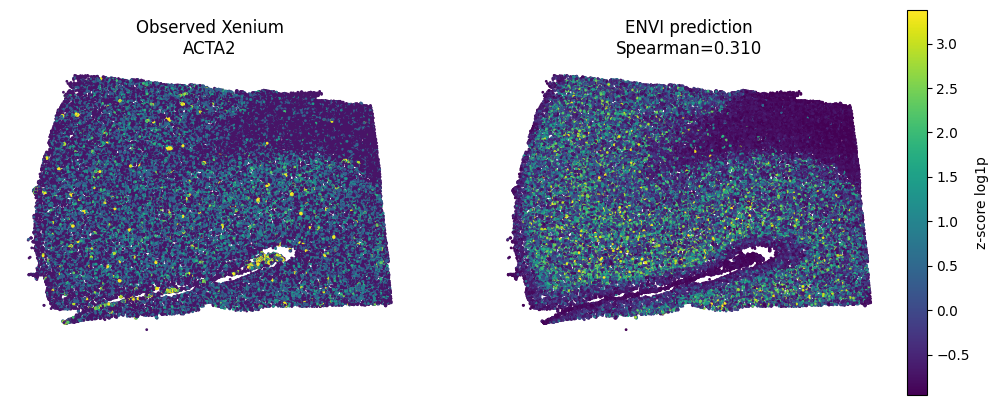

Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/envi/figures/17_envi_ACTA2_observed_vs_predicted_zscore.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/envi/figures/17_envi_ACTA2_observed_vs_predicted_zscore.pdf


In [11]:
gene_for_plot = GENE_FOR_PLOT

if gene_for_plot not in pred_adata.var_names:
    if "ACTA2" in pred_adata.var_names:
        gene_for_plot = "ACTA2"
    else:
        gene_for_plot = str(pred_adata.var_names[0])

plot_truth_vs_prediction_zscore(
    gene_for_plot,
    truth_eval,
    pred_adata,
    FIG_DIR / f"17_envi_{gene_for_plot}_observed_vs_predicted_zscore.png",
    FIG_DIR / f"17_envi_{gene_for_plot}_observed_vs_predicted_zscore.pdf",
)

Skipping VISTA: file missing: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/vista_validation_predictions_45genes.h5ad
Skipping gimVI: file missing: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/gimvi_validation_predictions_45genes.h5ad


Loaded SpaGE: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/spage_validation_predictions_45genes.h5ad
Loaded Tangram: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/tangram_validation_predictions_45genes_clusters.h5ad
Loaded ENVI: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/envi_validation_predictions_45genes.h5ad


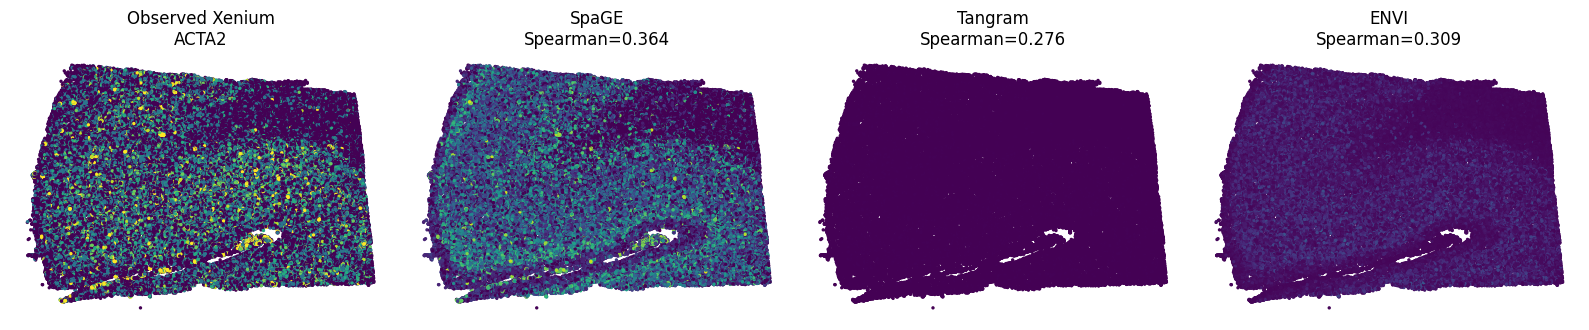

Saved all-method geneplot:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/method_comparison/figures/one_gene_ACTA2_observed_vs_methods_plus_envi.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/method_comparison/figures/one_gene_ACTA2_observed_vs_methods_plus_envi.pdf


In [12]:

# ============================================================
# 11. Optional all-method geneplot including ENVI
# ============================================================

METHOD_COMPARISON_DIR = PROJECT_ROOT / "outputs/imputation_beta/Br8667/validation/method_comparison"
METHOD_COMPARISON_FIG_DIR = METHOD_COMPARISON_DIR / "figures"
METHOD_COMPARISON_FIG_DIR.mkdir(parents=True, exist_ok=True)

method_files = {
    "VISTA": PRED_DIR / "vista_validation_predictions_45genes.h5ad",
    "gimVI": PRED_DIR / "gimvi_validation_predictions_45genes.h5ad",
    "SpaGE": PRED_DIR / "spage_validation_predictions_45genes.h5ad",
    "Tangram": PRED_DIR / "tangram_validation_predictions_45genes_clusters.h5ad",
    "ENVI": OUT_PRED_H5AD,
}

gene = gene_for_plot
available_methods = {}

for method, path in method_files.items():
    if path.exists():
        a = sc.read_h5ad(path)
        a.var_names = a.var_names.astype(str)
        if gene in a.var_names:
            common = truth_eval.obs_names.intersection(a.obs_names)
            if len(common) > 0:
                available_methods[method] = a[common, [gene]].copy()
                print(f"Loaded {method}: {path}")
            else:
                print(f"Skipping {method}: no shared cells")
        else:
            print(f"Skipping {method}: {gene} not in prediction")
    else:
        print(f"Skipping {method}: file missing: {path}")

if len(available_methods) > 0:
    common_cells = truth_eval.obs_names
    for a in available_methods.values():
        common_cells = common_cells.intersection(a.obs_names)

    truth_plot_adata = truth_eval[common_cells, [gene]].copy()
    coords = truth_plot_adata.obsm["spatial"]

    panels = [("Observed Xenium", truth_plot_adata)] + [
        (method, adata[common_cells, [gene]].copy())
        for method, adata in available_methods.items()
    ]

    values = [np.log1p(get_X_dense(a).ravel()) for _, a in panels]
    all_values = np.concatenate(values)
    vmin = np.nanpercentile(all_values, 1)
    vmax = np.nanpercentile(all_values, 99)

    n_panels = len(panels)
    fig = plt.figure(figsize=(4 * n_panels, 4))
    truth_raw = get_X_dense(truth_plot_adata).ravel()

    for i, (title, a) in enumerate(panels, start=1):
        ax = plt.subplot(1, n_panels, i)
        vals_raw = get_X_dense(a).ravel()
        vals = np.log1p(vals_raw)

        if title == "Observed Xenium":
            full_title = f"{title}\n{gene}"
        else:
            rho = spearmanr(truth_raw, vals_raw).correlation
            full_title = f"{title}\nSpearman={rho:.3f}"

        ax.scatter(coords[:, 0], coords[:, 1], c=vals, s=2, vmin=vmin, vmax=vmax)
        ax.set_title(full_title)
        ax.set_aspect("equal")
        ax.axis("off")

    plt.tight_layout()

    out_png = METHOD_COMPARISON_FIG_DIR / f"one_gene_{gene}_observed_vs_methods_plus_envi.png"
    out_pdf = METHOD_COMPARISON_FIG_DIR / f"one_gene_{gene}_observed_vs_methods_plus_envi.pdf"
    plt.savefig(out_png, dpi=300)
    plt.savefig(out_pdf)
    plt.show()

    print("Saved all-method geneplot:")
    print(out_png)
    print(out_pdf)
else:
    print("No existing method predictions found. ENVI-only geneplot was already saved.")



## Expected outputs

```text
data/processed/imputation_beta/Br8667/benchmark/predictions/
  envi_validation_predictions_45genes.h5ad

outputs/imputation_beta/Br8667/validation/envi/
  17_envi_validation_gene_metrics.csv
  17_envi_validation_summary.csv
  figures/
    17_envi_ACTA2_observed_vs_predicted.png
    17_envi_ACTA2_observed_vs_predicted.pdf
```

Optional all-method plot:

```text
outputs/imputation_beta/Br8667/validation/method_comparison/figures/
  one_gene_ACTA2_observed_vs_methods_plus_envi.png
  one_gene_ACTA2_observed_vs_methods_plus_envi.pdf
```
